# Финальный проект: Анализ продаж и погодных данных

## 1. Загрузка и просмотр данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Читаем файл
df = pd.read_csv('data.csv')

# Смотрим первые строки
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


## 2. Преобразование даты

In [2]:
df['Дата'] = pd.to_datetime(df['Дата'])

## 3. Группировка продаж по датам

In [4]:
grouped_df = df.groupby('Дата').size().reset_index(name='Количество_продаж')

In [5]:
print(grouped_df.head())

        Дата  Количество_продаж
0 2018-01-04               1840
1 2018-01-05               1301
2 2018-01-06               1306
3 2018-01-07               1322
4 2018-01-09               1719


### 4. Построение графика продаж

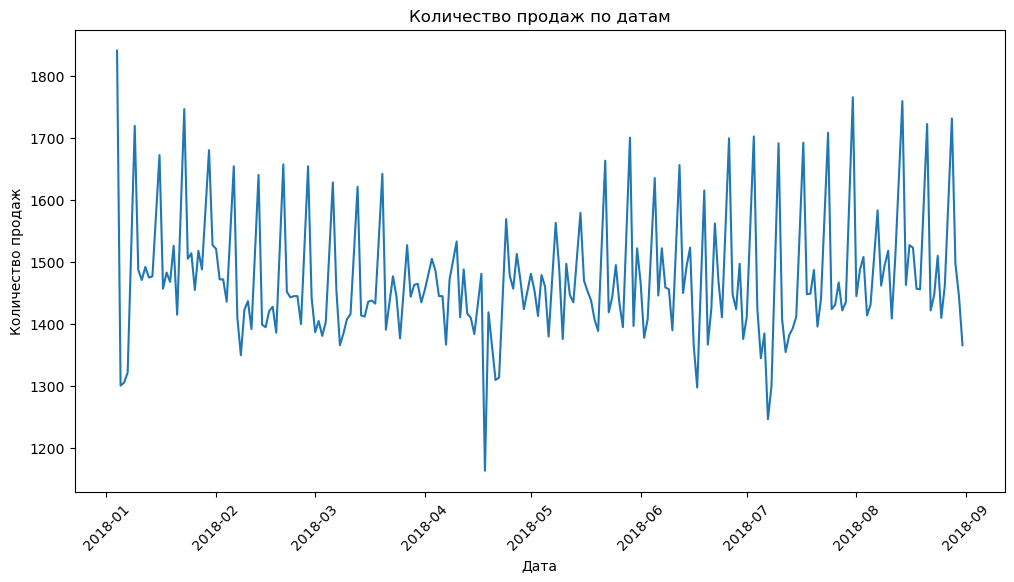

In [6]:
plt.figure(figsize=(12,6))

plt.plot(grouped_df['Дата'], grouped_df['Количество_продаж'])

plt.title('Количество продаж по датам')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')

plt.xticks(rotation=45)

plt.show()

# На графике показано изменение количества продаж по датам.
# По оси X расположены даты, по оси Y — количество продаж.
# Видно, что продажи меняются со временем: в некоторые дни наблюдаются пики,
# а в некоторые — снижение количества продаж.
# График помогает увидеть общую динамику продаж и возможные выбросы.

## 5. Поиск максимального выброса продаж

In [7]:
max_row = df[df['Количество'] == df['Количество'].max()]

print(max_row)

             Дата  Склад   Контрагент Номенклатура  Количество
218822 2018-06-28      1  address_208    product_0         200


## 6. Подготовка данных для анализа товаров

In [8]:
df['Месяц'] = df['Дата'].dt.month
df['День_недели'] = df['Дата'].dt.day_name()

## 7. Фильтрация данных по условиям

In [9]:
filtered_df = df[
    (df['Месяц'].isin([6, 7, 8])) &
    (df['День_недели'] == 'Wednesday') &
    (df['Склад'] == 3)
]

## 8. Определение самого продаваемого товара

In [10]:
top_product = filtered_df.groupby('Номенклатура')['Количество'].sum().sort_values(ascending=False)

print(top_product.head(1))

Номенклатура
product_1    2267
Name: Количество, dtype: int64


## 9. Загрузка и обработка погодных данных

In [11]:
weather_df = pd.read_csv('weather.csv', skiprows=6, sep=';')

print(weather_df.head())

                  Местное время в Астане      T     Po    P    Pa  \
31.12.2018 23:00                   -18.4  744.8  780.4  0.5  87.0   
31.12.2018 20:00                   -17.2  744.3  779.6  0.6  86.0   
31.12.2018 17:00                   -14.8  743.7  778.6  0.8  84.0   
31.12.2018 14:00                   -11.2  742.9  777.3  0.5  76.0   
31.12.2018 11:00                   -12.7  742.4  777.1  0.5  79.0   

                                                  U  DD  Ff  ff10  \
31.12.2018 23:00         Ветер, дующий с юго-запада   1 NaN   NaN   
31.12.2018 20:00                Ветер, дующий с юга   1 NaN   NaN   
31.12.2018 17:00  Ветер, дующий с западо-юго-запада   1 NaN   NaN   
31.12.2018 14:00  Ветер, дующий с западо-юго-запада   2 NaN   NaN   
31.12.2018 11:00    Ветер, дующий с юго-юго-востока   2 NaN   NaN   

                                        ff3  ...  \
31.12.2018 23:00  90  или более, но не 100%  ...   
31.12.2018 20:00  90  или более, но не 100%  ...   
31.12.2018 17:

## 10. Подготовка погодных данных

Из таблицы с погодными данными были выбраны столбцы с датой и температурой. Далее данные были преобразованы для последующего объединения с таблицей продаж.

In [12]:
weather_df = weather_df.reset_index()

weather_df = weather_df[['Местное время в Астане', 'T']]

weather_df.columns = ['Дата', 'Температура']

print(weather_df.head())

   Дата  Температура
0 -18.4        744.8
1 -17.2        744.3
2 -14.8        743.7
3 -11.2        742.9
4 -12.7        742.4


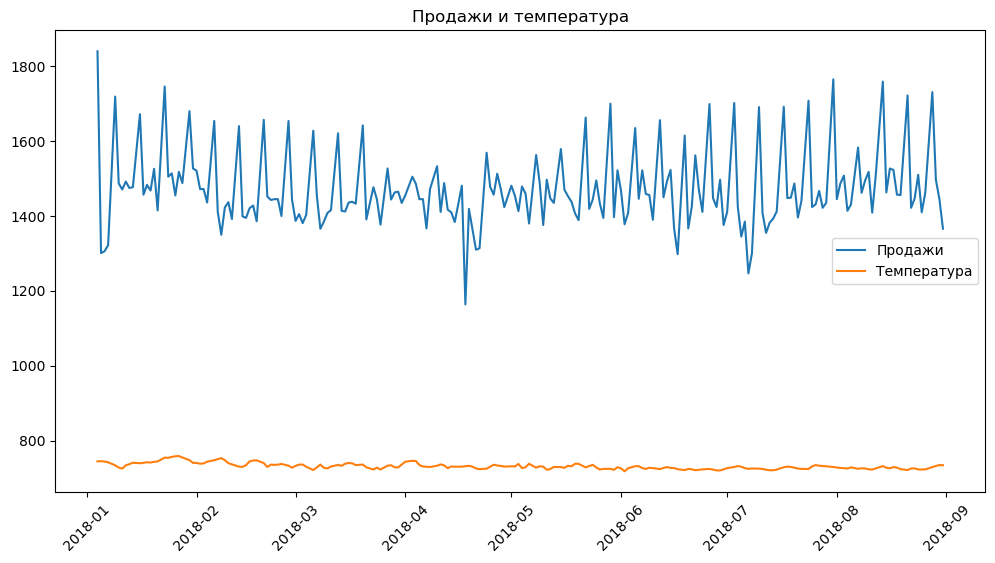

In [24]:
plt.figure(figsize=(12,6))

plt.plot(merged_df['Дата'], merged_df['Количество_продаж'], label='Продажи')

plt.plot(merged_df['Дата'], merged_df['Температура'], label='Температура')

plt.legend()

plt.title('Продажи и температура')

plt.xticks(rotation=45)

plt.show()

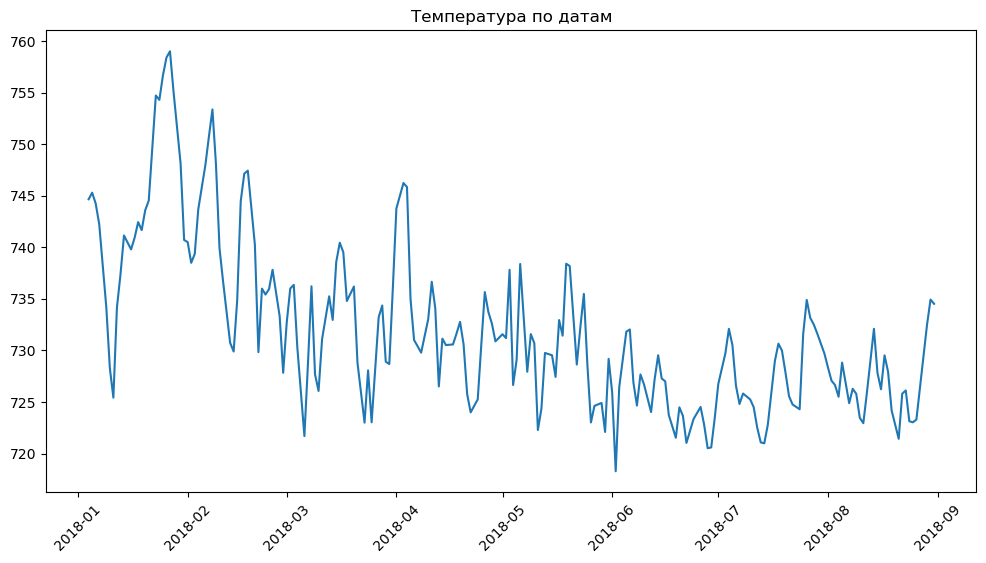

In [25]:
plt.figure(figsize=(12,6))

plt.plot(merged_df['Дата'], merged_df['Температура'])

plt.title('Температура по датам')

plt.xticks(rotation=45)

plt.show()